# Retrieval tuning

Finds values for the five search knobs in `config/config.yaml` by measuring how often
`hybrid_search` puts the right movie in the top 5.

| knob | what it does |
|---|---|
| `text-search-title-weight` / `-plot-` / `-genres-` | how the text arm ranks its matches |
| `rrf-k` | how strongly a top-ranked hit outweighs a lower one when fusing the two arms |
| `hybrid-search-n-candidates` | how many candidates each arm contributes |
| `hybrid-text-mode` | how the query becomes a tsquery (`all` / `any` / `fallback`) |

**Report only** — nothing here writes to `config.yaml`.

### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import os
# Everything below resolves paths from the repo root (config/, data/, models/).
# Guarded so re-running the cell, or running the notebook headless, is safe.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
# os.getcwd()

In [3]:
from tqdm.auto import tqdm

from cinevec.utils.file_utils import load_config_file
from cinevec.ingestion.db.build_rag_db import get_engine
from cinevec.ingestion.embed import get_embedder
from cinevec.agent.evaluate import (
    CachedEmbedder, SearchConfig, evaluate_config, sweep, weight_grid, fusion_grid,
)

config   = load_config_file()
engine   = get_engine()
embedder = get_embedder(config=config)

K = config.agent_max_results          # top-5, matching what the agent shows
sns.set_style("whitegrid")

CURRENT = SearchConfig(
    title=config.text_search_title_weight,
    plot=config.text_search_plot_weight,
    genres=config.text_search_genres_weight,
    rrf_k=config.rrf_k,
    n_candidates=config.hybrid_search_n_candidates,
    text_mode=config.hybrid_text_mode,
)
CURRENT

[2026-07-20 20:40:27,423: INFO: file_utils: Loaded YAML file from config/config.yaml]


SearchConfig(title=1.0, plot=0.4, genres=0.2, rrf_k=60, n_candidates=30, text_mode='fallback')

### The ground truth

500 movies, 5 short search-style queries each, written by an LLM from the plot. No query
names its own movie, so retrieval has to work from the description.

Queries are deliberately **short and keyword-ish** rather than full sentences. That is
forced by how the text arm works: under `text_mode="all"` every word must appear in the
same movie, and a plot is about two sentences, so a sentence-length query matches nothing
and the knobs have nothing to act on. See the caveats at the bottom.

In [4]:
import asyncio

from pydantic import BaseModel, Field
from pydantic_ai import Agent
from sqlalchemy import text

from cinevec.monitoring.metrics import compute_cost

N_MOVIES, WORKERS = 500, 8
MODEL = os.getenv("MOVIE_AGENT_MODEL", "openai:gpt-5.4-mini")

SYSTEM_PROMPT = """\
You write short search queries for a movie search engine.

Given one movie's plot, write exactly 5 queries somebody might type to find it.

Rules:
- 3 to 6 words each. Short, like a search box, not a sentence.
- NEVER use the movie's title or any word from it.
- NEVER name a character, actor, place or invented proper noun. Use roles
  instead: "a detective", "a small town".
- Use concrete nouns from the story (job, object, setting, creature, event),
  not abstract mood words. "boxer trains for rematch", not "gritty and moving".
- Vary them: a different aspect of the film each time.
"""

class Queries(BaseModel):
    queries: list[str] = Field(min_length=5, max_length=5)

# timeout matters: the OpenAI client defaults to 600s, so one hung request
# would block a worker for ten minutes with nothing printed. Calls normally
# take 1-3s, so 60s is generous and fails fast enough to retry.
qgen = Agent(MODEL, output_type=Queries, system_prompt=SYSTEM_PROMPT,
             model_settings={"timeout": 60})

[2026-07-20 20:40:31,032: INFO: file_utils: Loaded YAML file from config/config.yaml]


Sampled with a plot long enough to describe and enough votes to be a real film.
`md5(id)` ordering is a deterministic shuffle, so the same 500 movies come back every run.

In [5]:
with engine.connect() as conn:
    movies = conn.execute(text("""
        SELECT id, title, year, plot, genres
        FROM movies
        WHERE plot IS NOT NULL AND length(plot) >= 150
          AND vote_count >= 200 AND embedding IS NOT NULL
        ORDER BY md5(id::text)
        LIMIT :n
    """), {"n": N_MOVIES}).mappings().all()

print(f"{len(movies)} movies sampled")
pd.DataFrame([{"title": m["title"], "year": m["year"]} for m in movies]).head()

500 movies sampled


,title,year
0,The Grudge,2004
1,"Play It Again, Sam",1972
2,Chouchou,2003
3,Phoenix Forgotten,2017
4,Wheels on Meals,1984


Generated **only if the file does not exist yet**, the same rule
`load_and_store_data` uses for the dataset CSV. Delete
`data/ground-truth-retrieval.csv` to force a rebuild.

The file is written once, at the end, so it exists only when it is complete — a crash
part-way leaves no half-finished CSV for the next run to mistake for a real one.

In [6]:
GT_PATH = config.ground_truth_path

SEM = asyncio.Semaphore(WORKERS)

# Async, not threads: agent.run_sync inside a ThreadPoolExecutor builds a fresh
# event loop and HTTP client per worker and stalls badly past a few dozen calls
# (an hour for 50 movies, versus 16 seconds for 60 this way).
async def generate(movie):
    prompt = (f"Plot: {movie['plot']}\n"
              f"Genres: {', '.join(movie['genres'] or [])}\nYear: {movie['year']}")
    async with SEM:
        for attempt in range(3):
            try:
                result = await qgen.run(prompt)
                return movie, result.output.queries, result.usage
            except Exception as exc:
                if attempt == 2:
                    print(f"  giving up on {movie['title']}: {exc}")
                    return movie, None, None
                await asyncio.sleep(2 ** attempt)
    return movie, None, None


if os.path.exists(GT_PATH):
    print(f"{GT_PATH} already exists - skipping generation.")
else:
    print(f"generating {len(movies)} x 5 questions ...")
    results = await asyncio.gather(*(generate(m) for m in movies))

    rows, in_tok, out_tok = [], 0, 0
    for movie, queries, usage in results:
        if not queries:
            continue
        in_tok  += usage.input_tokens or 0
        out_tok += usage.output_tokens or 0
        rows.extend({"movie_id": movie["id"], "title": movie["title"], "question": q}
                    for q in queries)

    pd.DataFrame(rows).to_csv(GT_PATH, index=False)
    print(f"wrote {len(rows)} questions to {GT_PATH}  (cost ${compute_cost(in_tok, out_tok):.4f})")

./data/ground-truth-retrieval.csv already exists - skipping generation.


In [7]:
gt = pd.read_csv(config.ground_truth_path)
print(f"{len(gt)} questions for {gt.movie_id.nunique()} movies")
gt.head()

2500 questions for 500 movies


,movie_id,title,question
0,1970,The Grudge,american nurse tokyo curse
1,1970,The Grudge,supernatural rage killing curse
2,1970,The Grudge,haunted house curse deaths
3,1970,The Grudge,infectious rage ghost curse
4,1970,The Grudge,horror mystery in tokyo


The generator is told not to use the title, but it slips sometimes. A question containing
a distinctive title word makes retrieval trivial, so drop those before measuring.

In [8]:
STOP = {"the","a","an","of","and","in","on","to","part","ii","iii","movie","film","my","for"}

def leaks_title(row):
    words = {w for w in row.title.lower().replace(":", " ").replace("-", " ").split()
             if w not in STOP and len(w) > 3}
    q = row.question.lower()
    return any(w in q for w in words)

gt["leaks"] = gt.apply(leaks_title, axis=1)
print(f"dropping {gt.leaks.sum()} leaked questions ({gt.leaks.mean():.1%})")
gt = gt[~gt.leaks].drop(columns="leaks").reset_index(drop=True)
pairs = list(zip(gt.movie_id, gt.question))
print(f"{len(pairs)} questions kept")

dropping 193 leaked questions (7.7%)
2307 questions kept


### Embed once, reuse everywhere

`hybrid_search` embeds its query on every call, so a sweep of ~60 configs over 2500
questions would run 150k ONNX passes. `CachedEmbedder` serves precomputed vectors through
the same `.encode()` interface, turning that into one pass per question.

In [9]:
questions = list(dict.fromkeys(gt.question))
vectors = {}
for i in tqdm(range(0, len(questions), 256), desc="embedding"):
    chunk = questions[i:i+256]
    vectors.update(zip(chunk, embedder.encode_batch(chunk)))

cached = CachedEmbedder(vectors)
print(f"{len(vectors)} vectors cached")

embedding:   0%|          | 0/10 [00:00<?, ?it/s]

2307 vectors cached


### Stage 0 — baseline and text mode

`hit@5` is the share of questions whose movie lands in the top 5. `mrr@5` also rewards
putting it first.

The `text_mode` comparison matters most: under `all`, a sentence-length query needs every
word present in the same movie, which almost never happens — so the text arm returns
nothing and the other four knobs have no effect at all.

In [10]:
stage0 = sweep(engine, cached, pairs, [
    SearchConfig(CURRENT.title, CURRENT.plot, CURRENT.genres, CURRENT.rrf_k, CURRENT.n_candidates, m)
    for m in ("all", "any", "fallback")
], k=K, progress=tqdm)
stage0

  0%|          | 0/3 [00:00<?, ?it/s]

,title,plot,genres,rrf_k,n_candidates,text_mode,hit@5,mrr@5
0,1.0,0.4,0.2,60,30,fallback,0.371912,0.282690
1,1.0,0.4,0.2,60,30,all,0.355007,0.273472
2,1.0,0.4,0.2,60,30,any,0.259645,0.159731


In [11]:
BASELINE = stage0[stage0.text_mode == "all"].iloc[0]
print(f"baseline (text_mode='all', i.e. the original behaviour): "
      f"hit@{K}={BASELINE[f'hit@{K}']:.3f}  mrr@{K}={BASELINE[f'mrr@{K}']:.3f}")

BEST_MODE = stage0.iloc[0].text_mode
print(f"best text mode: {BEST_MODE!r}")

baseline (text_mode='all', i.e. the original behaviour): hit@5=0.355  mrr@5=0.273
best text mode: 'fallback'


### Stage 1 — text weights

`ts_rank` caps weights at 1.0 and its ranking is unchanged if all three are scaled by the
same constant. So every distinct ranking has a representative whose largest weight is
exactly 1.0 — `weight_grid` enumerates only those, which covers the space without
duplicates and, unlike pinning `title=1.0`, can still reach `plot > title`.

In [12]:
stage1 = sweep(engine, cached, pairs,
               weight_grid([0.2, 0.6, 1.0], CURRENT.rrf_k, CURRENT.n_candidates, BEST_MODE),
               k=K, progress=tqdm)
stage1.head(10)

  0%|          | 0/19 [00:00<?, ?it/s]

,title,plot,genres,rrf_k,n_candidates,text_mode,hit@5,mrr@5
0,0.2,1.0,0.6,60,30,fallback,0.501517,0.364470
1,0.2,1.0,1.0,60,30,fallback,0.499783,0.364044
2,0.2,1.0,0.2,60,30,fallback,0.499350,0.362896
3,1.0,1.0,0.6,60,30,fallback,0.491114,0.355700
4,1.0,1.0,1.0,60,30,fallback,0.489380,0.355310
5,1.0,1.0,0.2,60,30,fallback,0.488513,0.353829
6,0.6,1.0,1.0,60,30,fallback,0.483312,0.352391
7,0.6,1.0,0.6,60,30,fallback,0.483312,0.351365
8,0.6,1.0,0.2,60,30,fallback,0.480711,0.350361
9,0.6,0.6,1.0,60,30,fallback,0.479844,0.348765


In [13]:
best_w = stage1.iloc[0]
# bracket access, not .plot: pandas exposes .plot as the plotting accessor,
# so best_w.plot would return that object instead of the column.
WEIGHTS = {"title": best_w["title"], "plot": best_w["plot"], "genres": best_w["genres"]}
print("best weights:", WEIGHTS)

best weights: {'title': np.float64(0.2), 'plot': np.float64(1.0), 'genres': np.float64(0.6)}


### Stage 2 — fusion

In [14]:
stage2 = sweep(engine, cached, pairs,
               fusion_grid(WEIGHTS, [1, 5, 10, 20, 40, 60, 100],
                           [10, 20, 30, 50, 100], BEST_MODE),
               k=K, progress=tqdm)
stage2.head(10)

  0%|          | 0/35 [00:00<?, ?it/s]

,title,plot,genres,rrf_k,n_candidates,text_mode,hit@5,mrr@5
0,0.2,1.0,0.6,5,100,fallback,0.522323,0.383882
1,0.2,1.0,0.6,5,50,fallback,0.521890,0.384988
2,0.2,1.0,0.6,5,30,fallback,0.520590,0.384626
3,0.2,1.0,0.6,5,20,fallback,0.520156,0.383008
4,0.2,1.0,0.6,1,50,fallback,0.517555,0.387119
5,0.2,1.0,0.6,1,100,fallback,0.517555,0.385515
6,0.2,1.0,0.6,1,30,fallback,0.516688,0.387235
7,0.2,1.0,0.6,10,20,fallback,0.516255,0.375466
8,0.2,1.0,0.6,1,10,fallback,0.515821,0.381296
9,0.2,1.0,0.6,10,100,fallback,0.515821,0.373790


**Most of this table is a tie.** The top rows differ by fractions of a point:

| rrf_k | n_candidates | hit@5 |
|---|---|---|
| 5 | 100 | 0.5223 |
| 5 | 50 | 0.5219 |
| 5 | 30 | 0.5206 |
| 5 | 20 | 0.5202 |

A 0.2pp spread over a 5x range of `n_candidates`, and measured latency is flat across it
too (5.6ms at 20, 6.3ms at 100). So `n_candidates` is not really tunable on this ground
truth — any value in 20–100 is defensible, and picking the argmax is picking noise.

`rrf_k` is different: 1 and 5 clearly beat 10, 20, 40 and 60, and that gap is real. Same for
the weights, where plot 1.0 / title 0.2 beats the alternatives by several points.

### Stage 3 — did staging cost us anything?

Stage 1 tuned the weights at the *old* fusion settings. Re-running that grid at the stage-2
winner checks whether the two dimensions interact.

Across two runs of this notebook the flag came out
`True` once and `False` once, and in the `False` run the "new winner" beat the old one by
**0.09pp** (0.5232 vs 0.5223). That is not an interaction, it is noise: ~76 configs are
scored here, so the argmax is optimistically biased and the top handful are
indistinguishable. Treat the flag as informative only if the gap is larger than the
confidence interval printed further down.

In [15]:
best_f = stage2.iloc[0]
stage3 = sweep(engine, cached, pairs,
               weight_grid([0.2, 0.6, 1.0], int(best_f.rrf_k), int(best_f.n_candidates), BEST_MODE),
               k=K, progress=tqdm)

top3 = stage3.iloc[0]
same = (top3["title"], top3["plot"], top3["genres"]) == \
       (best_w["title"], best_w["plot"], best_w["genres"])
print("stage 1 winner still wins at the new fusion settings:", same)
stage3.head(5)

  0%|          | 0/19 [00:00<?, ?it/s]

stage 1 winner still wins at the new fusion settings: False


,title,plot,genres,rrf_k,n_candidates,text_mode,hit@5,mrr@5
0,0.2,1.0,1.0,5,100,fallback,0.523190,0.383593
1,0.2,1.0,0.6,5,100,fallback,0.522323,0.383882
2,0.2,1.0,0.2,5,100,fallback,0.519289,0.383095
3,1.0,1.0,1.0,5,100,fallback,0.517122,0.374491
4,1.0,1.0,0.6,5,100,fallback,0.516688,0.375285


### Results

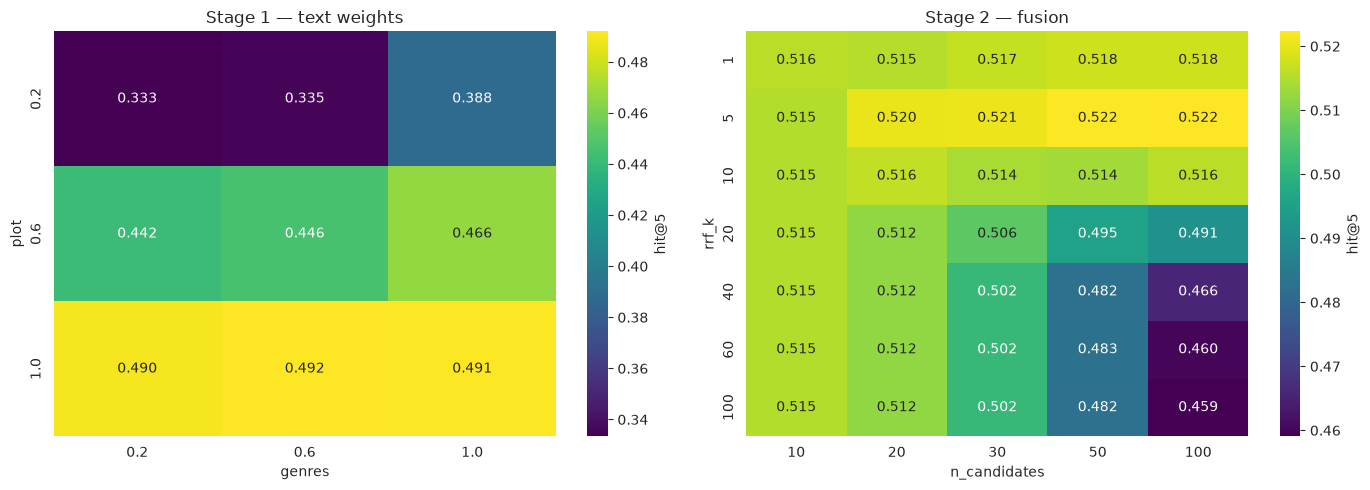

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, idx, col, title) in zip(axes, [
    (stage1, "plot", "genres", "Stage 1 — text weights"),
    (stage2, "rrf_k", "n_candidates", "Stage 2 — fusion"),
]):
    piv = df.pivot_table(index=idx, columns=col, values=f"hit@{K}")
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                cbar_kws={"label": f"hit@{K}"})
    ax.set_title(title)
plt.tight_layout()
plt.show()

**How much of a difference is real?** Each movie contributes 5 correlated questions, so the
effective sample is nearer 500 independent items than 2500. A paired bootstrap over movies
gives the honest interval on the improvement.

In [17]:
def paired_bootstrap(engine, embedder, pairs, cfg_a, cfg_b, k=K, n_boot=1000, seed=0):
    """CI on hit@k difference, resampling movies (not questions) since the
    5 questions of one movie are not independent."""
    from cinevec.agent.evaluate import _search_one
    from concurrent.futures import ThreadPoolExecutor

    def hits(cfg):
        with ThreadPoolExecutor(max_workers=8) as pool:
            ranked = list(pool.map(lambda q: _search_one(engine, embedder, q, cfg, k),
                                   [q for _, q in pairs]))
        return np.array([want in ids[:k] for ids, (want, _) in zip(ranked, pairs)], dtype=float)

    a, b = hits(cfg_a), hits(cfg_b)
    movies = np.array([m for m, _ in pairs])
    uniq = np.unique(movies)
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        pick = rng.choice(uniq, size=len(uniq), replace=True)
        mask = np.concatenate([np.where(movies == m)[0] for m in pick])
        diffs.append(a[mask].mean() - b[mask].mean())
    return a.mean() - b.mean(), np.percentile(diffs, [2.5, 97.5])

BEST = SearchConfig(WEIGHTS["title"], WEIGHTS["plot"], WEIGHTS["genres"],
                    int(best_f.rrf_k), int(best_f.n_candidates), BEST_MODE)
diff, (lo, hi) = paired_bootstrap(engine, cached, pairs, BEST, CURRENT)
print(f"best vs current: {diff:+.4f} hit@{K}   95% CI [{lo:+.4f}, {hi:+.4f}]")
print("significant" if lo > 0 else "NOT significant - keep the current values")

best vs current: +0.1504 hit@5   95% CI [+0.1354, +0.1678]
significant


In [18]:
print(f"""
# --- paste into config/config.yaml ---
# hit@{K} {BEST_MODE}: {stage2.iloc[0][f'hit@{K}']:.3f}   vs current {BASELINE[f'hit@{K}']:.3f}
# 95% CI on the difference: [{lo:+.4f}, {hi:+.4f}]
text-search-title-weight: {WEIGHTS['title']}
text-search-plot-weight: {WEIGHTS['plot']}
text-search-genres-weight: {WEIGHTS['genres']}
hybrid-search-n-candidates: {int(best_f.n_candidates)}
rrf-k: {int(best_f.rrf_k)}
hybrid-text-mode: "{BEST_MODE}"
""")


# --- paste into config/config.yaml ---
# hit@5 fallback: 0.522   vs current 0.355
# 95% CI on the difference: [+0.1354, +0.1678]
text-search-title-weight: 0.2
text-search-plot-weight: 1.0
text-search-genres-weight: 0.6
hybrid-search-n-candidates: 100
rrf-k: 5
hybrid-text-mode: "fallback"



### What this does and does not tell you

- **The questions are short search-box queries, not the sentences the agent actually sends.**
  That was forced: under `text_mode="all"` a sentence matches nothing, so there would have
  been no signal to tune on at all.
- **Known-item retrieval is a proxy.** "Find the film I just described" is measurable;
  "recommend me something good" is not. Weights that win here are a sensible default, not a
  validated recommendation optimum.
- **Tuned on `hybrid_search` only.** `mode="text"` uses `ts_rank` over the whole match set
  rather than a pool-limited candidate list, so the weights are assumed — not shown — to
  transfer.
- **~60 configs were scored**, so the top one is optimistically biased. The bootstrap CI
  against the current config is the number to trust, not the raw maximum.
- **Only some of the tuned parameters carry real signal.** `text_mode`, the plot and title
  weights, and `rrf_k` move the metric by points. `n_candidates` and the genres weight move
  it by fractions of a point — the genres weight is measurably non-zero (+0.7pp from off to
  0.6, paired CI excludes zero) but small; `n_candidates` is indistinguishable across 20–100.
  Change the first group deliberately; treat the second as taste.
- Results are specific to `Xenova/all-MiniLM-L6-v2` and this 10k-row snapshot.